## Alignment - MNIST example

Goals:

* Show alignment methods on real learned data
* train vaes and construct manifolds
* plot manifolds with data (three classes)

Hypothesis: 
* If latent distributions are non-symmetric AND geometry is non-symmetric, then GW can find a unique minimizer (for all classes iff the classes have inter distinguishable distributions) and in theory a perfect alignment.

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import torch
import pandas as pd

from sklearn.decomposition import PCA
from scipy.optimize import minimize
from scipy.stats import vonmises_fisher
from scipy.spatial.distance import cdist, pdist, squareform

from colors import color_segment
from supervised_vae import SupervisedVAE
from train_two_vaes import train_two_vaes
from plot_vaes import plot_vae_latent_alignment
from utils_GW import *

blue_pink = color_segment()

In [5]:
# load vaes from checkpoints instead of training new ones
# Instantiate the models
vaeA = SupervisedVAE(latent_dim=8, num_classes=3)
vaeB = SupervisedVAE(latent_dim=8, num_classes=3)

classes = '3classes'

# Load the state dicts
vaeA.load_state_dict(torch.load(f"checkpoints/mnist_same_{classes}_vaeA.pt"))
vaeB.load_state_dict(torch.load(f"checkpoints/mnist_same_{classes}_vaeB.pt"))

# Load latent variables
zA_dict = torch.load(f"checkpoints/mnist_same_{classes}_zA.pt")
zB_dict = torch.load(f"checkpoints/mnist_same_{classes}_zB.pt")

zA = zA_dict["z"]
zB = zB_dict["z"]
y = zA_dict["y"]  # or zB_dict["y"], since yA and yB should be the same

In [ ]:
# # train vaes
# vaeA, vaeB, zA, zB, y = train_two_vaes(
#     device="cpu",
#     epochs=15,
#     latent_dim=8,
#     prefix="checkpoints/mnist_same_classes",
#     num_classes=3,
#     seedA=0,
#     seedB=42
# )

Training VAE_A...
[Epoch   1] Loss=193.5448 Recon=188.0639 KL=4.5711 CLS=0.9099
[Epoch   2] Loss=134.6009 Recon=125.4307 KL=8.6795 CLS=0.4907
[Epoch   3] Loss=119.4224 Recon=108.2441 KL=10.7939 CLS=0.3843
[Epoch   4] Loss=113.0289 Recon=101.3004 KL=11.4091 CLS=0.3194
[Epoch   5] Loss=109.1963 Recon=97.2170 KL=11.7049 CLS=0.2745
[Epoch   6] Loss=105.4920 Recon=93.0653 KL=12.1911 CLS=0.2356
[Epoch   7] Loss=103.2219 Recon=90.4266 KL=12.5857 CLS=0.2096
[Epoch   8] Loss=101.2209 Recon=88.1373 KL=12.8936 CLS=0.1899
[Epoch   9] Loss=99.6128 Recon=86.2287 KL=13.2070 CLS=0.1771
[Epoch  10] Loss=98.2170 Recon=84.5916 KL=13.4575 CLS=0.1678
[Epoch  11] Loss=97.0673 Recon=83.2100 KL=13.6985 CLS=0.1587
[Epoch  12] Loss=95.8085 Recon=81.7531 KL=13.9082 CLS=0.1472
[Epoch  13] Loss=95.0379 Recon=80.8712 KL=14.0281 CLS=0.1386
[Epoch  14] Loss=94.3473 Recon=80.0946 KL=14.1211 CLS=0.1317
[Epoch  15] Loss=93.6860 Recon=79.3256 KL=14.2350 CLS=0.1254
Training VAE_B...
[Epoch   1] Loss=195.5822 Recon=190.200

In [6]:
def pca_project_np(X, n_components=2):
    X = np.asarray(X)
    assert X.ndim == 2
    assert 1 <= n_components <= X.shape[1]

    X_centered = X - X.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    return X_centered @ Vt[:n_components].T


def plot_vae_latent_alignment(zA, zB, y, zB_aligned=None, title_suffix=""):
    """
    Plot latent spaces in a shared 2D PCA projection.

    Inputs
    ------
    zA : (N, d) array
        Reference latent space.
    zB : (N, d) array
        Target latent space before alignment.
    y : (N,) array
        Integer class labels.
    zB_aligned : (N, d) array or None
        Target latent space after alignment. If None, only two panels are shown.
    title_suffix : str
        Optional text appended to the figure title.
    """
    zA = np.asarray(zA)
    zB = np.asarray(zB)
    y = np.asarray(y)

    assert zA.ndim == 2
    assert zB.ndim == 2
    assert y.ndim == 1
    assert zA.shape == zB.shape
    assert zA.shape[0] == len(y)

    labels = np.unique(y)
    assert len(labels) <= 10, "This plotting function supports at most 10 classes."

    if zB_aligned is None:
        Z_all = np.vstack([zA, zB])
        Z_all_2d = pca_project_np(Z_all, n_components=2)

        n = zA.shape[0]
        zA_2d = Z_all_2d[:n]
        zB_2d = Z_all_2d[n:]

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes = np.asarray(axes)
    else:
        zB_aligned = np.asarray(zB_aligned)
        assert zB_aligned.shape == zA.shape

        Z_all = np.vstack([zA, zB, zB_aligned])
        Z_all_2d = pca_project_np(Z_all, n_components=2)

        n = zA.shape[0]
        zA_2d = Z_all_2d[:n]
        zB_2d = Z_all_2d[n:2*n]
        zB_aligned_2d = Z_all_2d[2*n:]

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        axes = np.asarray(axes)

    class_colors = [
        "tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple",
        "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"
    ]

    label_to_color = {label: class_colors[i] for i, label in enumerate(labels)}

    for label in labels:
        mask = (y == label)
        color = label_to_color[label]

        axes[0].scatter(
            zA_2d[mask, 0],
            zA_2d[mask, 1],
            s=10,
            alpha=0.75,
            color=color,
            label=str(label)
        )

        axes[1].scatter(
            zB_2d[mask, 0],
            zB_2d[mask, 1],
            s=10,
            alpha=0.75,
            color=color,
            label=str(label)
        )

        if zB_aligned is not None:
            axes[2].scatter(
                zB_aligned_2d[mask, 0],
                zB_aligned_2d[mask, 1],
                s=10,
                alpha=0.75,
                color=color,
                label=str(label)
            )

    axes[0].set_title("zA (reference)")
    axes[1].set_title("zB (before)")
    if zB_aligned is not None:
        axes[2].set_title("zB (aligned)")

    for ax in axes:
        ax.set_aspect("equal")
        ax.legend(title="class", loc="best")
        ax.grid(alpha=0.2)

    if title_suffix:
        fig.suptitle(f"Latent alignment {title_suffix}")
    else:
        fig.suptitle("Latent alignment")

    plt.tight_layout()
    plt.show()


def plot_vae_latent_overlay(zA, zB_aligned, y, title="Overlay: zA vs zB_aligned"):
    """
    Overlay reference and aligned latent spaces in a shared 2D PCA projection.

    Inputs
    ------
    zA : (N, d) array
        Reference latent space.
    zB_aligned : (N, d) array
        Aligned target latent space.
    y : (N,) array
        Integer class labels.
    """
    zA = np.asarray(zA)
    zB_aligned = np.asarray(zB_aligned)
    y = np.asarray(y)

    assert zA.ndim == 2
    assert zB_aligned.ndim == 2
    assert y.ndim == 1
    assert zA.shape == zB_aligned.shape
    assert zA.shape[0] == len(y)

    labels = np.unique(y)
    assert len(labels) <= 10, "This plotting function supports at most 10 classes."

    Z_all = np.vstack([zA, zB_aligned])
    Z_all_2d = pca_project_np(Z_all, n_components=2)

    n = zA.shape[0]
    zA_2d = Z_all_2d[:n]
    zB_2d = Z_all_2d[n:]

    class_colors = [
        "tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple",
        "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"
    ]
    label_to_color = {label: class_colors[i] for i, label in enumerate(labels)}

    plt.figure(figsize=(7, 7))

    for label in labels:
        mask = (y == label)
        color = label_to_color[label]

        plt.scatter(
            zA_2d[mask, 0],
            zA_2d[mask, 1],
            s=12,
            alpha=0.65,
            color=color,
            marker="o",
            label=f"A-{label}"
        )

        plt.scatter(
            zB_2d[mask, 0],
            zB_2d[mask, 1],
            s=18,
            alpha=0.75,
            color=color,
            marker="x",
            label=f"B-{label}"
        )

    plt.title(title)
    plt.gca().set_aspect("equal")
    plt.grid(alpha=0.2)
    plt.legend(loc="best", ncol=2)
    plt.tight_layout()
    plt.show()

The learned latent spaces are not simply related by one rotation for the whole space. They differ by:

* rotation
* reflection (flip)
* anisotropic scaling
* class-dependent distortions

#### Unpaired alignment: Using labels from both A and B

solving a quadratic assignment problem... search space ~ . 

In [7]:
def permute_within_labels(z, y, seed=0):
    rng = np.random.default_rng(seed)

    z_perm = np.empty_like(z)
    y_perm = y.copy()
    perm_map = np.empty(len(y), dtype=int)

    for k in np.unique(y):
        idx = np.where(y == k)[0]
        perm_idx = rng.permutation(idx)

        z_perm[idx] = z[perm_idx]
        perm_map[idx] = perm_idx

    return z_perm, y_perm, perm_map


def undo_within_label_permutation(z_perm_aligned, y, perm_map):
    z_restored = np.empty_like(z_perm_aligned)

    for k in np.unique(y):
        idx = np.where(y == k)[0]
        original_idx = perm_map[idx]
        z_restored[original_idx] = z_perm_aligned[idx]

    return z_restored


def learn_labelwise_gw_orthogonal_maps(zA, zB, y, labels=None, epsilon=0.02, threshold=1e-6):
    if labels is None:
        labels = np.unique(y)

    maps = {}
    couplings = {}
    losses = {}

    for k in labels:
        XA = zA[y == k]
        XB = zB[y == k]

        assert XA.ndim == 2 and XB.ndim == 2
        assert XA.shape[1] == XB.shape[1]
        assert XA.shape[0] > 0 and XB.shape[0] > 0

        D_A = compute_pairwise_distances(XA)
        D_B = compute_pairwise_distances(XB)

        assert D_A.shape == (XA.shape[0], XA.shape[0])
        assert D_B.shape == (XB.shape[0], XB.shape[0])

        P, gw_loss = solve_gw_coupling(
            D_A,
            D_B,
            epsilon=epsilon,
            threshold=threshold
        )

        assert P.shape == (XA.shape[0], XB.shape[0])

        R, t = fit_orthogonal_map_from_coupling(XA, XB, P)

        assert R.shape == (XA.shape[1], XA.shape[1])
        assert t.shape == (XA.shape[1],)

        maps[k] = {"R": R, "t": t}
        couplings[k] = P
        losses[k] = gw_loss

    return maps, couplings, losses


def apply_labelwise_orthogonal_maps(z, y, maps):
    z_aligned = np.zeros_like(z)

    for k, params in maps.items():
        mask = (y == k)
        R = params["R"]
        t = params["t"]

        assert z[mask].shape[1] == R.shape[0]
        assert R.shape[0] == R.shape[1]
        assert t.shape[0] == R.shape[1]

        z_aligned[mask] = z[mask] @ R + t

    return z_aligned


def paired_alignment_metrics(z_ref, z_aligned, y):
    assert z_ref.shape == z_aligned.shape
    assert z_ref.shape[0] == len(y)

    rows = []
    total_err = np.linalg.norm(z_ref - z_aligned, axis=1)

    for k in np.unique(y):
        mask = (y == k)
        err = np.linalg.norm(z_ref[mask] - z_aligned[mask], axis=1)

        rows.append({
            "label": int(k),
            "n": int(mask.sum()),
            "mean_l2": float(err.mean()),
            "median_l2": float(np.median(err)),
            "max_l2": float(err.max()),
            "rmse": float(np.sqrt(np.mean(err ** 2)))
        })

    rows.append({
        "label": "all",
        "n": int(len(y)),
        "mean_l2": float(total_err.mean()),
        "median_l2": float(np.median(total_err)),
        "max_l2": float(total_err.max()),
        "rmse": float(np.sqrt(np.mean(total_err ** 2)))
    })

    return pd.DataFrame(rows)


def cross_space_1nn_accuracy(z_query, y_query, z_ref, y_ref):
    assert z_query.ndim == 2 and z_ref.ndim == 2
    assert z_query.shape[1] == z_ref.shape[1]
    assert z_query.shape[0] == len(y_query)
    assert z_ref.shape[0] == len(y_ref)

    dists = cdist(z_query, z_ref, metric="euclidean")
    nn_idx = np.argmin(dists, axis=1)
    y_pred = y_ref[nn_idx]
    return float(np.mean(y_pred == y_query))


def subsample_per_label(z, y, max_per_label=500, seed=0):
    rng = np.random.default_rng(seed)

    keep_idx = []
    for k in np.unique(y):
        idx = np.where(y == k)[0]
        m = min(max_per_label, len(idx))
        chosen = rng.choice(idx, size=m, replace=False)
        keep_idx.append(np.sort(chosen))

    keep_idx = np.concatenate(keep_idx)
    keep_idx = np.sort(keep_idx)

    return z[keep_idx], y[keep_idx], keep_idx



In [10]:
# Convert saved checkpoint tensors to numpy
zA_np = zA.detach().cpu().numpy() if torch.is_tensor(zA) else np.asarray(zA)
zB_np = zB.detach().cpu().numpy() if torch.is_tensor(zB) else np.asarray(zB)
y_np = y.detach().cpu().numpy() if torch.is_tensor(y) else np.asarray(y)

assert zA_np.ndim == 2
assert zB_np.ndim == 2
assert y_np.ndim == 1
assert zA_np.shape == zB_np.shape
assert zA_np.shape[0] == len(y_np)

# First subsample matched pairs using the same indices in both spaces
zA_small, y_small, keep_idx = subsample_per_label(
    zA_np, y_np, max_per_label=50, seed=0
)
zB_small = zB_np[keep_idx]

assert zA_small.ndim == 2
assert zB_small.ndim == 2
assert y_small.ndim == 1
assert zA_small.shape == zB_small.shape
assert zA_small.shape[0] == len(y_small)
assert np.array_equal(y_small, y_np[keep_idx])

labels = np.unique(y_small)

# Then break the hidden pointwise correspondence within each class
zB_small_perm, y_small_perm, perm_map = permute_within_labels(
    zB_small, y_small, seed=7
)

assert zB_small_perm.shape == zB_small.shape
assert np.array_equal(y_small_perm, y_small)

# Learn one GW-based orthogonal map per class on the subsampled data
maps, couplings, gw_losses = learn_labelwise_gw_orthogonal_maps(
    zA=zA_small,
    zB=zB_small_perm,
    y=y_small,
    labels=labels,
    epsilon=0.02,
    threshold=1e-5
)

# Align and restore original order for paired evaluation
zB_small_perm_aligned = apply_labelwise_orthogonal_maps(
    zB_small_perm, y_small_perm, maps
)
zB_small_aligned = undo_within_label_permutation(
    zB_small_perm_aligned, y_small, perm_map
)

assert zB_small_aligned.shape == zA_small.shape

# Evaluate against the hidden true pairing on the subsampled set
metrics_df = paired_alignment_metrics(
    z_ref=zA_small,
    z_aligned=zB_small_aligned,
    y=y_small
)

acc_before = cross_space_1nn_accuracy(
    zB_small, y_small, zA_small, y_small
)
acc_after = cross_space_1nn_accuracy(
    zB_small_aligned, y_small, zA_small, y_small
)

print("full zA shape:", zA_np.shape)
print("full zB shape:", zB_np.shape)
print("subsampled zA shape:", zA_small.shape)
print("subsampled zB shape:", zB_small.shape)

print("\nPer-class GW losses:")
for k in labels:
    print(f"label {k}: {gw_losses[k]:.6f}")

print("\n1-NN label transfer accuracy on subsampled set")
print(f"before alignment: {acc_before:.4f}")
print(f"after alignment:  {acc_after:.4f}")

metrics_df

full zA shape: (18623, 8)
full zB shape: (18623, 8)
subsampled zA shape: (150, 8)
subsampled zB shape: (150, 8)

Per-class GW losses:
label 0: 0.052322
label 1: 0.055110
label 2: 0.055542

1-NN label transfer accuracy on subsampled set
before alignment: 0.5533
after alignment:  0.9200


,label,n,mean_l2,median_l2,max_l2,rmse
0,0,50,2.847708,2.773563,4.908857,2.988295
1,1,50,1.977513,1.986806,3.719474,2.091822
2,2,50,3.438261,3.244147,5.808116,3.663152
3,all,150,2.754494,2.582241,5.808116,2.984644


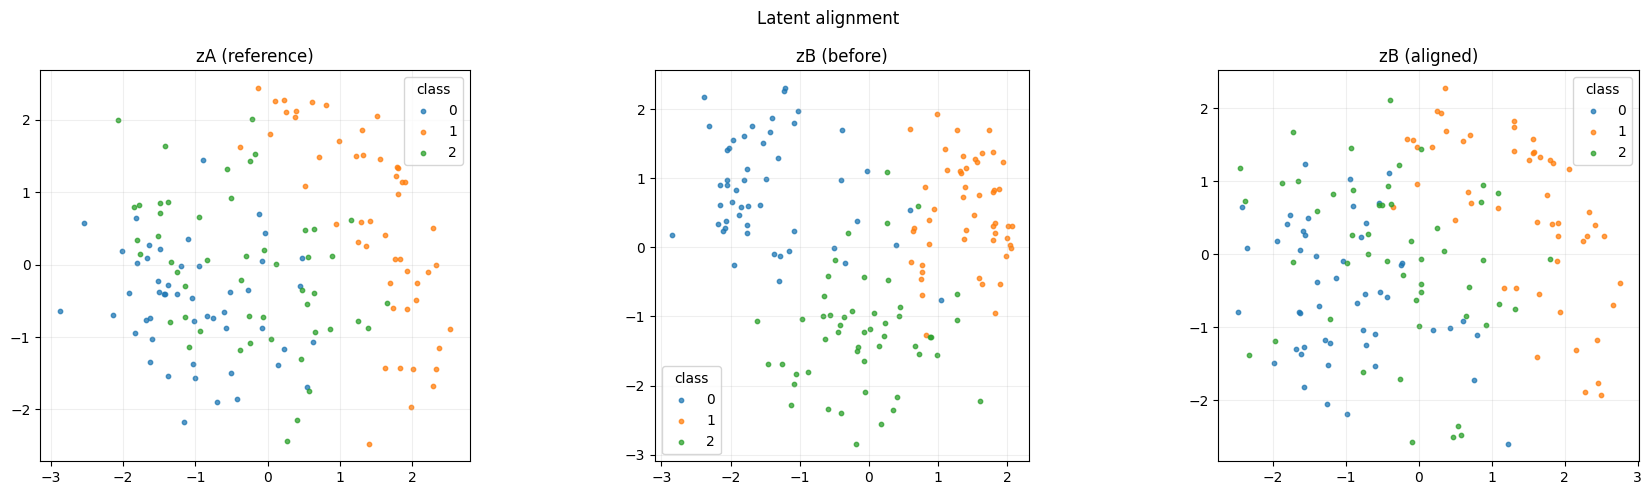

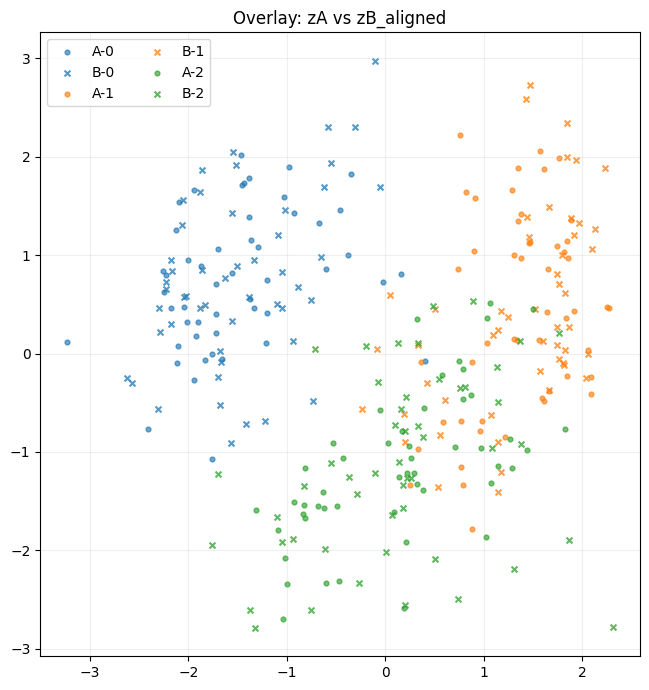

In [11]:
plot_vae_latent_alignment(zA_small, zB_small, y_small, zB_small_aligned)
plot_vae_latent_overlay(zA_small, zB_small_aligned, y_small)

Cross space nearest neighbor classification metric siger at efter alignment er strukturen god nok til at klassifikere mere rigtigt end før alignment.

In [7]:
print("Class means distance BEFORE:")
for k in labels:
    mA = zA_small[y_small == k].mean(axis=0)
    mB = zB_small[y_small == k].mean(axis=0)
    print(k, np.linalg.norm(mA - mB))

print("\nClass means distance AFTER:")
for k in labels:
    mA = zA_small[y_small == k].mean(axis=0)
    mB = zB_small_aligned[y_small == k].mean(axis=0)
    print(k, np.linalg.norm(mA - mB))

Class means distance BEFORE:
1 1.2587562
2 1.8077842
3 2.3330977

Class means distance AFTER:
1 6.318514e-07
2 7.049368e-07
3 5.293584e-07


Efter alignment er class means utrolig tæt på source class means. men vi har også et translation led i loss så de skal være tæt på hinanden, men det betyder ikke at hele classes er godt aligned... viser ikke at GW virker til at mappe intern class struktur.

+ har ingen loss der sepererer classes

In [9]:
print("Paired mean L2 error BEFORE:")
for k in labels:
    mask = (y_small == k)
    err = np.linalg.norm(zA_small[mask] - zB_small[mask], axis=1)
    print(k, err.mean())

print("\nPaired mean L2 error AFTER:")
for k in labels:
    mask = (y_small == k)
    err = np.linalg.norm(zA_small[mask] - zB_small_aligned[mask], axis=1)
    print(k, err.mean())

Paired mean L2 error BEFORE:
1 3.2770922
2 3.7539566
3 3.8453224

Paired mean L2 error AFTER:
1 1.3314966
2 3.0262733
3 1.9712411


^^ "hvor tæt ligger de to repræsentationer af samme billede før og efter alignment" ^^ (vi bruger labels fra begge)

In [11]:

def plot_alignment_pca(zA, zB, zB_aligned, y, title_suffix=""):
    pca = PCA(n_components=2)
    Z_all = np.vstack([zA, zB, zB_aligned])
    Z_all_2d = pca.fit_transform(Z_all)

    n = len(zA)
    zA_2d = Z_all_2d[:n]
    zB_2d = Z_all_2d[n:2*n]
    zB_aligned_2d = Z_all_2d[2*n:]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for k in np.unique(y):
        mask = (y == k)

        axes[0].scatter(zA_2d[mask, 0], zA_2d[mask, 1], s=5, label=str(k))
        axes[1].scatter(zB_2d[mask, 0], zB_2d[mask, 1], s=5, label=str(k))
        axes[2].scatter(zB_aligned_2d[mask, 0], zB_aligned_2d[mask, 1], s=5, label=str(k))

    axes[0].set_title("zA (reference)")
    axes[1].set_title("zB (before)")
    axes[2].set_title("zB (aligned)")

    for ax in axes:
        ax.legend()
        ax.set_aspect("equal")

    plt.suptitle("Latent alignment " + title_suffix)
    plt.show()

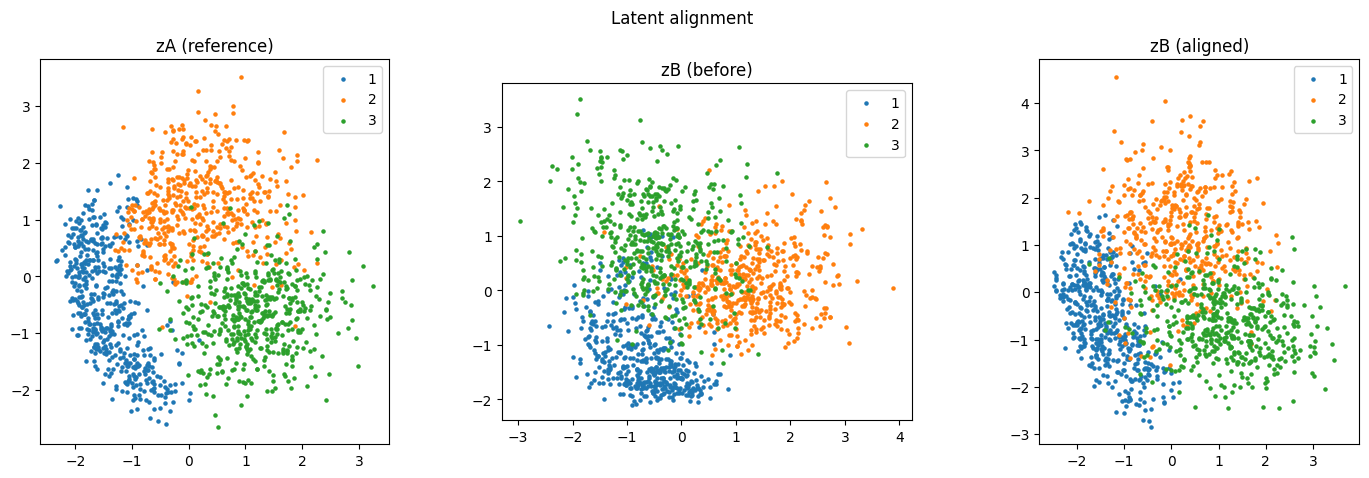

In [12]:
plot_alignment_pca(zA_small, zB_small, zB_small_aligned, y_small)

In [15]:
def plot_overlay(zA, zB_aligned, y):
    from sklearn.decomposition import PCA

    Z = np.vstack([zA, zB_aligned])
    Z2 = PCA(n_components=2).fit_transform(Z)

    n = len(zA)
    zA_2d = Z2[:n]
    zB_2d = Z2[n:]

    plt.figure(figsize=(6,6))

    for k in np.unique(y):
        mask = (y == k)

        plt.scatter(zA_2d[mask, 0], zA_2d[mask, 1],
                    s=5, label=f"A-{k}", alpha=0.6)

        plt.scatter(zB_2d[mask, 0], zB_2d[mask, 1],
                    s=5, marker='x', label=f"B-{k}", alpha=0.6)

    plt.legend()
    plt.title("Overlay: zA vs zB_aligned")
    plt.gca().set_aspect("equal")
    plt.show()

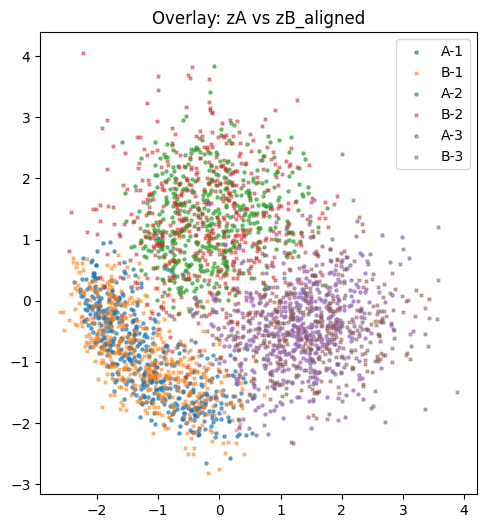

In [14]:
plot_overlay(zA_small, zB_small_aligned, y_small)

^^ k wise matched classes - multiple maps ^^

**Global map:**

In [12]:
# ---- trying to find one global map ----
def subsample_per_label(z, y, max_per_label=150, seed=0):
    rng = np.random.default_rng(seed)

    keep_idx = []
    for k in np.unique(y):
        idx = np.where(y == k)[0]
        m = min(max_per_label, len(idx))
        chosen = rng.choice(idx, size=m, replace=False)
        keep_idx.append(np.sort(chosen))

    keep_idx = np.concatenate(keep_idx)
    keep_idx = np.sort(keep_idx)

    return z[keep_idx], y[keep_idx], keep_idx


def permute_globally(z, seed=0):
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(z))
    z_perm = z[perm]
    return z_perm, perm


def undo_global_permutation(z_perm_aligned, perm):
    z_restored = np.empty_like(z_perm_aligned)
    z_restored[perm] = z_perm_aligned
    return z_restored


def learn_global_gw_orthogonal_map(zA, zB, epsilon=0.02, threshold=1e-6):
    assert zA.ndim == 2 and zB.ndim == 2
    assert zA.shape == zB.shape

    D_A = compute_pairwise_distances(zA)
    D_B = compute_pairwise_distances(zB)

    assert D_A.shape == (zA.shape[0], zA.shape[0])
    assert D_B.shape == (zB.shape[0], zB.shape[0])

    P, gw_loss = solve_gw_coupling(
        D_A,
        D_B,
        epsilon=epsilon,
        threshold=threshold
    )

    assert P.shape == (zA.shape[0], zB.shape[0])

    R, t = fit_orthogonal_map_from_coupling(zA, zB, P)

    assert R.shape == (zA.shape[1], zA.shape[1])
    assert t.shape == (zA.shape[1],)

    return {"R": R, "t": t}, P, gw_loss


def apply_global_orthogonal_map(z, map_params):
    R = map_params["R"]
    t = map_params["t"]

    assert z.shape[1] == R.shape[0]
    assert R.shape[0] == R.shape[1]
    assert t.shape[0] == R.shape[1]

    return z @ R + t

In [13]:
# Convert saved checkpoint tensors to numpy
zA_np = zA.detach().cpu().numpy() if torch.is_tensor(zA) else np.asarray(zA)
zB_np = zB.detach().cpu().numpy() if torch.is_tensor(zB) else np.asarray(zB)
y_np = y.detach().cpu().numpy() if torch.is_tensor(y) else np.asarray(y)

assert zA_np.shape == zB_np.shape
assert zA_np.shape[0] == len(y_np)

# Subsample matched hidden pairs, but keep labels only for evaluation
zA_small, y_small, keep_idx = subsample_per_label(
    zA_np, y_np, max_per_label=150, seed=0
)
zB_small = zB_np[keep_idx]

assert zA_small.shape == zB_small.shape
assert np.array_equal(y_small, y_np[keep_idx])

# Destroy hidden pointwise correspondences globally
zB_small_perm, perm = permute_globally(zB_small, seed=7)

# Learn one global GW coupling and one global rigid map
global_map, P_global, gw_loss_global = learn_global_gw_orthogonal_map(
    zA=zA_small,
    zB=zB_small_perm,
    epsilon=0.02,
    threshold=1e-6
)

# Align and restore original order for evaluation
zB_small_perm_aligned = apply_global_orthogonal_map(zB_small_perm, global_map)
zB_small_aligned = undo_global_permutation(zB_small_perm_aligned, perm)

assert zB_small_aligned.shape == zA_small.shape

# Evaluate
metrics_df = paired_alignment_metrics(
    z_ref=zA_small,
    z_aligned=zB_small_aligned,
    y=y_small
)

acc_before = cross_space_1nn_accuracy(
    zB_small, y_small, zA_small, y_small
)
acc_after = cross_space_1nn_accuracy(
    zB_small_aligned, y_small, zA_small, y_small
)

print("subsampled shape:", zA_small.shape)
print("global GW loss:", gw_loss_global)

print("\n1-NN label transfer accuracy")
print(f"before alignment: {acc_before:.4f}")
print(f"after alignment:  {acc_after:.4f}")

metrics_df

subsampled shape: (450, 8)
global GW loss: 0.029886481328446707

1-NN label transfer accuracy
before alignment: 0.6200
after alignment:  0.9133


,label,n,mean_l2,median_l2,max_l2,rmse
0,0,150,2.650184,2.516935,6.043331,2.796305
1,1,150,2.297569,2.128458,6.166221,2.467571
2,2,150,3.223637,3.134298,7.903882,3.494399
3,all,450,2.723797,2.535672,7.903882,2.950652


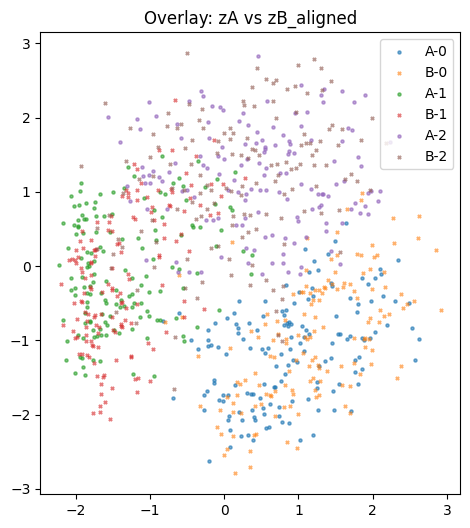

In [16]:
plot_overlay(zA_small, zB_small_aligned, y_small)

for these classes there exist a commen global good enough alignment, it is not a perfect alignment.

In [5]:

if "torch" in str(type(zA)):
    zA_np = zA.detach().cpu().numpy()
    zB_np = zB.detach().cpu().numpy()
    y_np = y.detach().cpu().numpy()
else:
    zA_np = zA
    zB_np = zB
    y_np = y

labels = np.unique(y_np)

maps, couplings, losses = learn_labelwise_gw_maps(
    zA_np,
    zB_np,
    y_np,
    labels=labels,
    epsilon=0.1,
    threshold=1e-6,
)

zB_aligned = apply_labelwise_maps(zB_np, y_np, maps)

print("Per-class GW losses:")
for k in labels:
    print(f"digit {k}: {losses[k]:.6f}")

Per-class GW losses:
digit 1: 0.029156
digit 2: 0.024174
digit 3: 0.022741


In [11]:
def plot_class_alignment(label, dims=(0,1), s=6):
    XA = zA_np[y_np == label]
    XB = zB_np[y_np == label]
    XB_aligned = zB_aligned[y_np == label]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # A
    axes[0].scatter(XA[:, dims[0]], XA[:, dims[1]], s=s)
    axes[0].set_title(f"A | digit {label}")
    axes[0].axis("equal")

    # B (before)
    axes[1].scatter(XB[:, dims[0]], XB[:, dims[1]], s=s)
    axes[1].set_title(f"B | digit {label}")
    axes[1].axis("equal")

    # aligned overlay
    axes[2].scatter(XA[:, dims[0]], XA[:, dims[1]], s=s, alpha=0.5, label="A")
    axes[2].scatter(XB_aligned[:, dims[0]], XB_aligned[:, dims[1]], s=s, alpha=0.5, label="B aligned")
    axes[2].set_title(f"Aligned | digit {label}")
    axes[2].legend()
    axes[2].axis("equal")

    plt.tight_layout()
    plt.show()

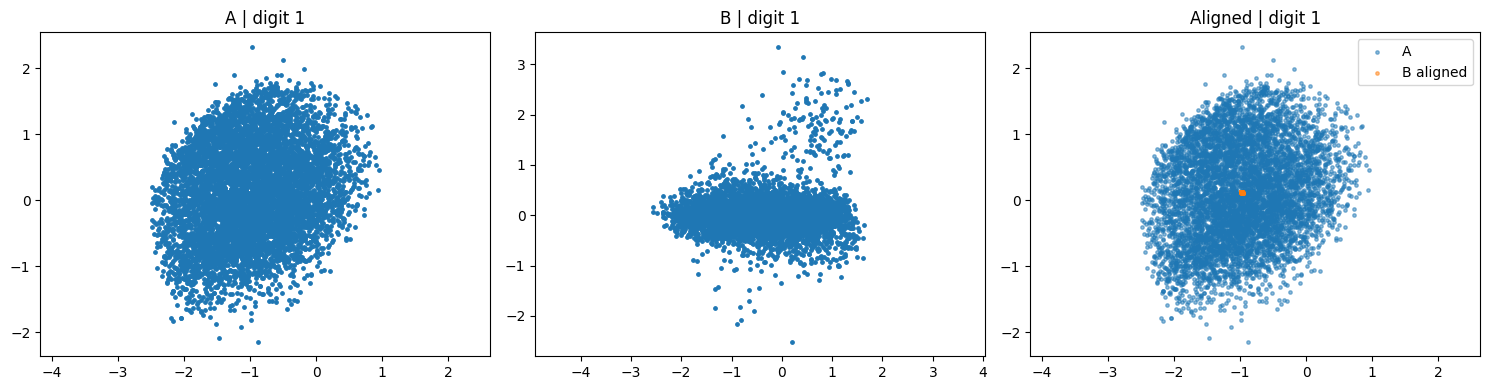

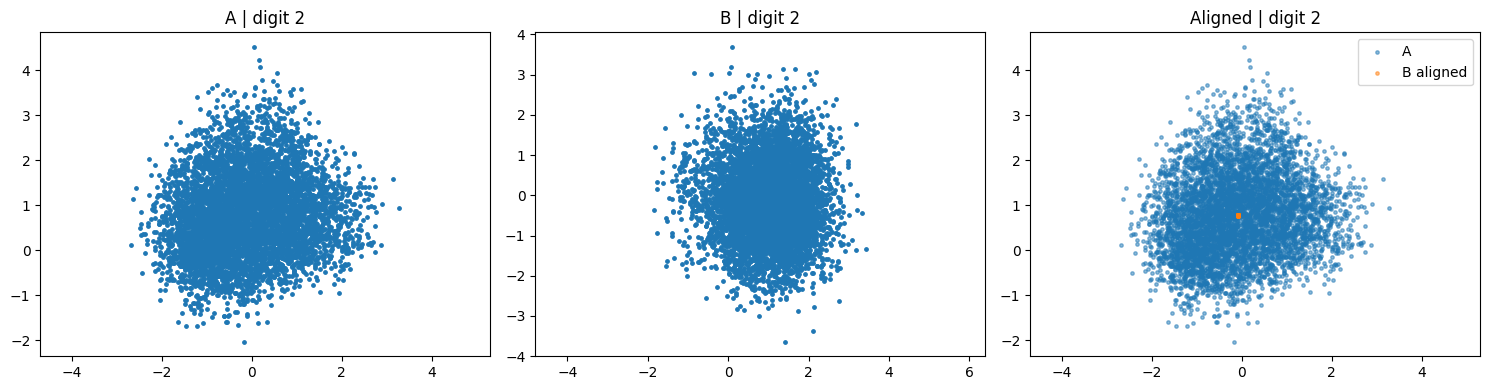

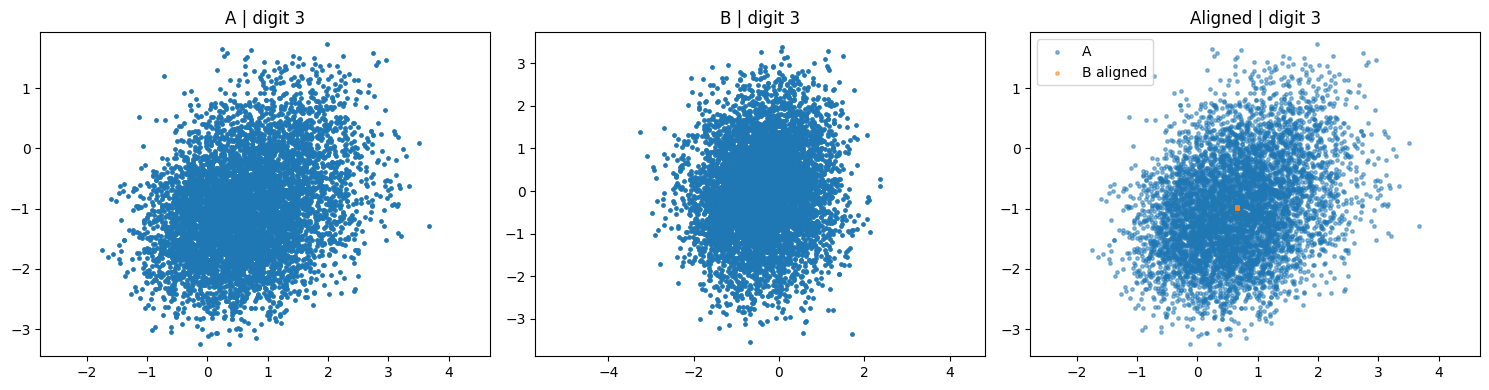

In [12]:
for k in np.unique(y_np):
    plot_class_alignment(k)

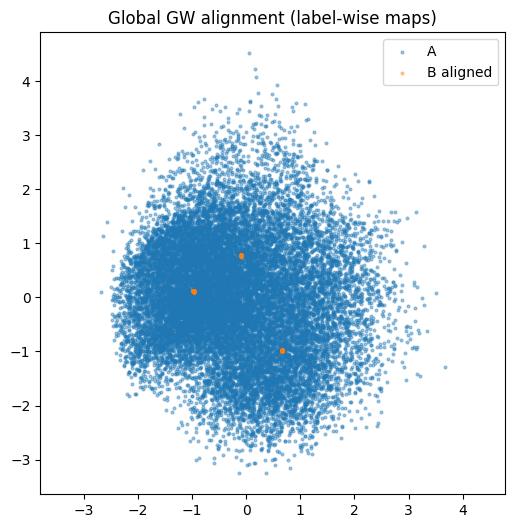

In [8]:
plt.figure(figsize=(6,6))

plt.scatter(zA_np[:,0], zA_np[:,1], s=4, alpha=0.4, label="A")
plt.scatter(zB_aligned[:,0], zB_aligned[:,1], s=4, alpha=0.4, label="B aligned")

plt.legend()
plt.axis("equal")
plt.title("Global GW alignment (label-wise maps)")
plt.show()

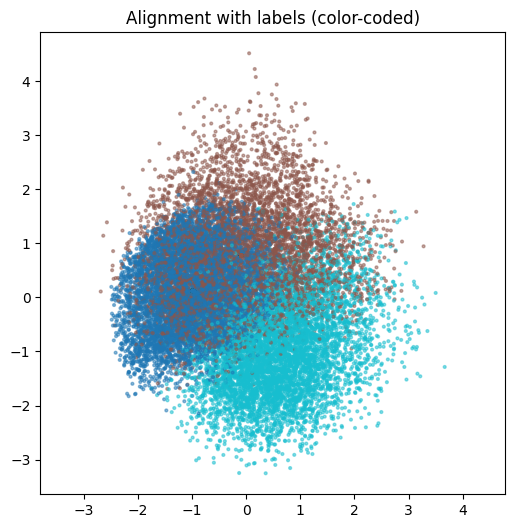

In [9]:
plt.figure(figsize=(6,6))

plt.scatter(zA_np[:,0], zA_np[:,1], c=y_np, cmap="tab10", s=4, alpha=0.5)
plt.scatter(zB_aligned[:,0], zB_aligned[:,1], c=y_np, cmap="tab10", s=4, alpha=0.5)

plt.axis("equal")
plt.title("Alignment with labels (color-coded)")
plt.show()

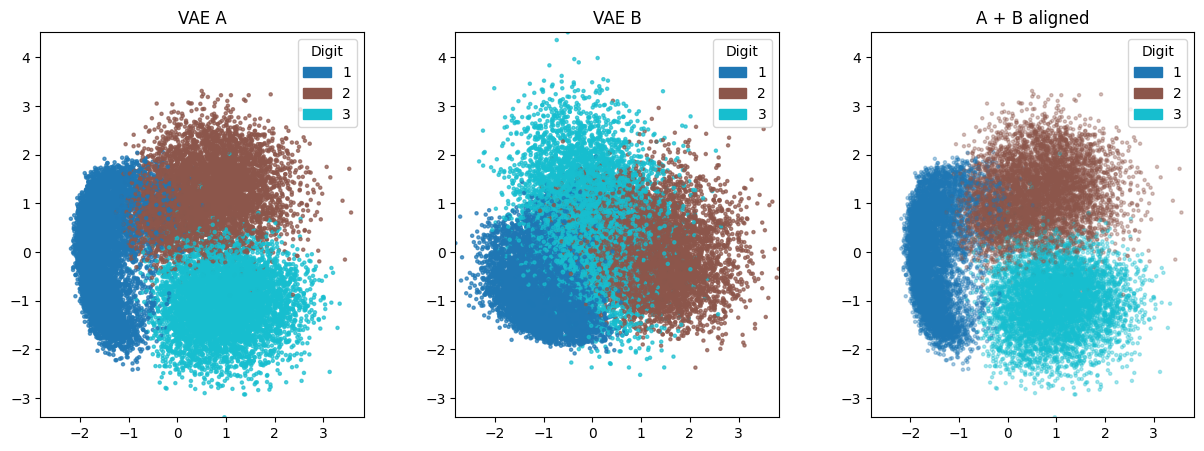

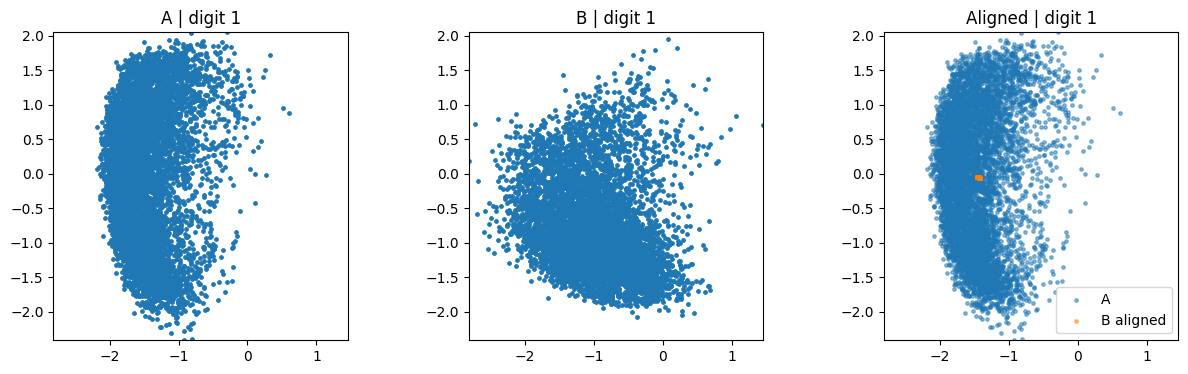

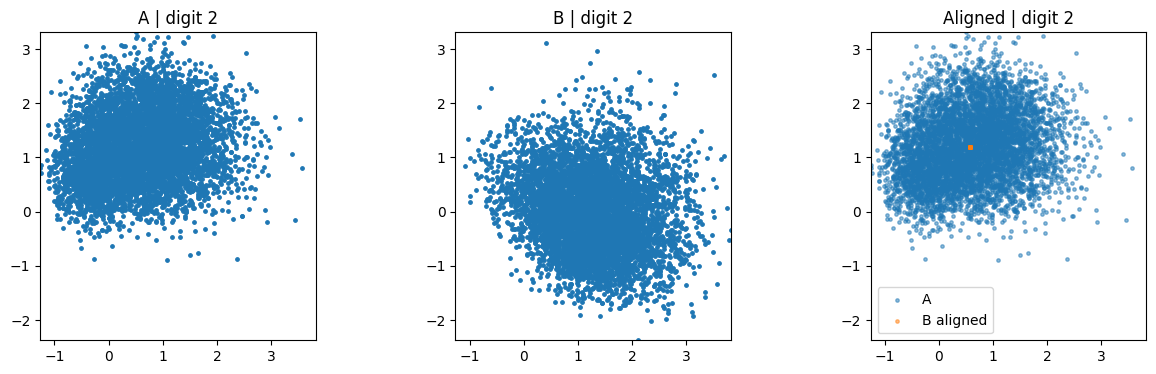

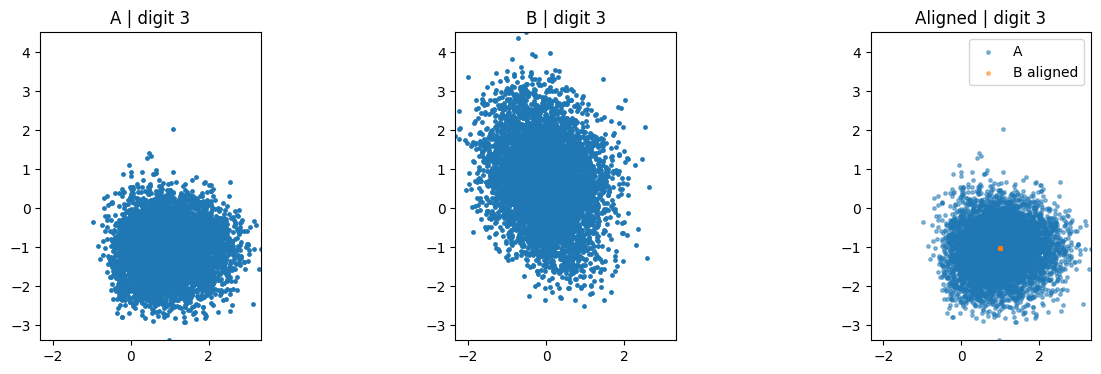

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA

# --------------------------------------------------
# Convert to numpy if needed
# --------------------------------------------------
if "torch" in str(type(zA)):
    zA_np = zA.detach().cpu().numpy()
    zB_np = zB.detach().cpu().numpy()
    y_np = y.detach().cpu().numpy()
else:
    zA_np = zA
    zB_np = zB
    y_np = y

# zB_aligned is assumed already computed

# --------------------------------------------------
# Shared PCA for all three sets
# --------------------------------------------------
Z_all = np.vstack([zA_np, zB_np, zB_aligned])

pca = PCA(n_components=2)
Z_all_2d = pca.fit_transform(Z_all)

n = len(zA_np)
zA_2d = Z_all_2d[:n]
zB_2d = Z_all_2d[n:2*n]
zB_aligned_2d = Z_all_2d[2*n:]

labels = np.unique(y_np)

# --------------------------------------------------
# Global plot: A, B, and aligned B
# --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sc1 = axes[0].scatter(
    zA_2d[:, 0], zA_2d[:, 1],
    c=y_np, cmap="tab10",
    s=5, alpha=0.7
)
axes[0].set_title("VAE A")

axes[1].scatter(
    zB_2d[:, 0], zB_2d[:, 1],
    c=y_np, cmap="tab10",
    s=5, alpha=0.7
)
axes[1].set_title("VAE B")

axes[2].scatter(
    zA_2d[:, 0], zA_2d[:, 1],
    c=y_np, cmap="tab10",
    s=5, alpha=0.35, label="A"
)
axes[2].scatter(
    zB_aligned_2d[:, 0], zB_aligned_2d[:, 1],
    c=y_np, cmap="tab10",
    s=5, alpha=0.35, marker="x", label="B aligned"
)
axes[2].set_title("A + B aligned")

# shared limits manually
x_min = min(zA_2d[:, 0].min(), zB_2d[:, 0].min(), zB_aligned_2d[:, 0].min())
x_max = max(zA_2d[:, 0].max(), zB_2d[:, 0].max(), zB_aligned_2d[:, 0].max())
y_min = min(zA_2d[:, 1].min(), zB_2d[:, 1].min(), zB_aligned_2d[:, 1].min())
y_max = max(zA_2d[:, 1].max(), zB_2d[:, 1].max(), zB_aligned_2d[:, 1].max())

for ax in axes:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect("equal", adjustable="box")

# shared legend
cmap = sc1.cmap
norm = sc1.norm
legend_handles = []
for lbl in labels:
    color = cmap(norm(lbl))
    legend_handles.append(mpatches.Patch(color=color, label=str(int(lbl))))

for ax in axes:
    ax.legend(handles=legend_handles, title="Digit", loc="upper right")

plt.subplots_adjust(wspace=0.25)
plt.show()

# --------------------------------------------------
# Per-class plot function in the SAME PCA coordinates
# --------------------------------------------------
def plot_class_alignment_shared_pca(label, s=6):
    XA = zA_2d[y_np == label]
    XB = zB_2d[y_np == label]
    XB_aligned = zB_aligned_2d[y_np == label]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].scatter(XA[:, 0], XA[:, 1], s=s)
    axes[0].set_title(f"A | digit {label}")
    axes[0].set_aspect("equal", adjustable="box")

    axes[1].scatter(XB[:, 0], XB[:, 1], s=s)
    axes[1].set_title(f"B | digit {label}")
    axes[1].set_aspect("equal", adjustable="box")

    axes[2].scatter(XA[:, 0], XA[:, 1], s=s, alpha=0.5, label="A")
    axes[2].scatter(XB_aligned[:, 0], XB_aligned[:, 1], s=s, alpha=0.5, label="B aligned")
    axes[2].set_title(f"Aligned | digit {label}")
    axes[2].legend()
    axes[2].set_aspect("equal", adjustable="box")

    # same limits inside class plot
    x_min = min(XA[:, 0].min(), XB[:, 0].min(), XB_aligned[:, 0].min())
    x_max = max(XA[:, 0].max(), XB[:, 0].max(), XB_aligned[:, 0].max())
    y_min = min(XA[:, 1].min(), XB[:, 1].min(), XB_aligned[:, 1].min())
    y_max = max(XA[:, 1].max(), XB[:, 1].max(), XB_aligned[:, 1].max())

    for ax in axes:
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)

    plt.subplots_adjust(wspace=0.25)
    plt.show()

# --------------------------------------------------
# Plot all classes
# --------------------------------------------------
for k in labels:
    plot_class_alignment_shared_pca(k)